# MIDI comparison for game, classical, and pop music

This notebook compares broad musical features across three corpora:
- `game_midi`
- `classical_midi`
- `pop_midi`

The goal is to test whether game music tends to be sparser, more repetitive in a softer way, and harmonically less goal-directed than classical or pop music.

In [1]:
from pathlib import Path
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

BASE_DIR = Path.cwd()
DATASETS = {
    'game': BASE_DIR / 'game_midi',
    'classical': BASE_DIR / 'classical_midi',
    'pop': BASE_DIR / 'pop_midi',
}

for label, folder in DATASETS.items():
    print(label, folder.exists(), folder)

game False /Users/margo/Desktop/game_music/game_midi
classical False /Users/margo/Desktop/game_music/classical_midi
pop False /Users/margo/Desktop/game_music/pop_midi


In [5]:
import os
import numpy as np
import pandas as pd
from collections import Counter

import pretty_midi
from scipy.stats import entropy

import matplotlib.pyplot as plt

# -----------------------------
# CHANGE THESE PATHS
# -----------------------------

CLASSICAL_DIR = "sampled_datasets/classical_midi"
POP_DIR = "sampled_datasets/pop_midi"
GAME_DIR = "sampled_datasets/game_midi"

# -----------------------------
# FEATURE FUNCTIONS
# -----------------------------

def rhythmic_entropy(pm):
    durations = []

    for instrument in pm.instruments:
        for note in instrument.notes:
            dur = round(note.end - note.start, 2)
            durations.append(dur)

    if len(durations) == 0:
        return np.nan

    counts = Counter(durations)
    probs = np.array(list(counts.values())) / len(durations)

    return entropy(probs)


def rhythmic_repetition(pm, n=4):
    durations = []

    for instrument in pm.instruments:
        for note in instrument.notes:
            dur = round(note.end - note.start, 2)
            durations.append(dur)

    if len(durations) < n:
        return np.nan

    ngrams = [
        tuple(durations[i:i+n])
        for i in range(len(durations)-n+1)
    ]

    counts = Counter(ngrams)

    repeated = sum(v for v in counts.values() if v > 1)

    return repeated / len(ngrams)


def pitch_entropy(pm):
    pitches = []

    for instrument in pm.instruments:
        for note in instrument.notes:
            pitches.append(note.pitch % 12)

    if len(pitches) == 0:
        return np.nan

    counts = Counter(pitches)
    probs = np.array(list(counts.values())) / len(pitches)

    return entropy(probs)


def chord_diversity(pm):
    chroma = pm.get_chroma()

    if chroma.shape[1] == 0:
        return np.nan

    chord_sequence = []

    for t in range(chroma.shape[1]):
        active = tuple(np.where(chroma[:, t] > 0)[0])
        chord_sequence.append(active)

    unique_chords = len(set(chord_sequence))

    return unique_chords / len(chord_sequence)


# -----------------------------
# PROCESS DATASET
# -----------------------------

def process_folder(folder, genre):
    rows = []

    for file in os.listdir(folder):

        if not (file.endswith(".mid") or file.endswith(".midi")):
            continue

        path = os.path.join(folder, file)

        try:
            pm = pretty_midi.PrettyMIDI(path)

            row = {
                "genre": genre,
                "file": file,
                "rhythmic_entropy": rhythmic_entropy(pm),
                "rhythmic_repetition": rhythmic_repetition(pm),
                "pitch_entropy": pitch_entropy(pm),
                "chord_diversity": chord_diversity(pm),
            }

            rows.append(row)

            print("processed:", file)

        except Exception as e:
            print("failed:", file, e)

    return rows


all_rows = []

all_rows += process_folder(CLASSICAL_DIR, "classical")
all_rows += process_folder(POP_DIR, "pop")
all_rows += process_folder(GAME_DIR, "game")

df = pd.DataFrame(all_rows)

print(df.head())

# -----------------------------
# SAVE RESULTS
# -----------------------------

df.to_csv("music_features.csv", index=False)

# -----------------------------
# SUMMARY
# -----------------------------

summary = df.groupby("genre").mean(numeric_only=True)

print(summary)

# -----------------------------
# PLOTS
# -----------------------------

features = [
    "rhythmic_entropy",
    "rhythmic_repetition",
    "pitch_entropy",
    "chord_diversity"
]

for feature in features:

    plt.figure(figsize=(6,4))

    groups = [
        df[df["genre"] == g][feature].dropna()
        for g in ["classical", "pop", "game"]
    ]

    plt.boxplot(groups, labels=["classical", "pop", "game"])

    plt.title(feature)
    plt.ylabel(feature)

    plt.tight_layout()
    plt.savefig(f"{feature}.png")
    plt.close()

print("done")

processed: haydn_43_1.mid
processed: ty_august.mid
processed: muss_2.mid
processed: waldstein_1.mid
processed: schumm-1.mid
processed: chpn_op23.mid
processed: chpn-p19.mid
processed: chpn_op7_2.mid
processed: beethoven_opus90_2.mid
processed: chpn-p18.mid
processed: chpn-p24.mid
processed: mendel_op19_1.mid
processed: grieg_kobold.mid
processed: muss_3.mid
processed: haydn_43_2.mid
processed: muss_1.mid
processed: burg_sylphen.mid
processed: waldstein_2.mid
processed: schumm-2.mid
processed: burg_quelle.mid
processed: mendel_op19_3.mid
processed: schub_d960_4.mid
processed: chpn_op7_1.mid
processed: schum_abegg.mid
processed: gra_esp_4.mid
processed: islamei.mid
processed: beethoven_opus90_1.mid
processed: mendel_op19_2.mid
processed: schumm-3.mid
processed: waldstein_3.mid
processed: haydn_8_4.mid
processed: haydn_43_3.mid
processed: muss_4.mid
processed: bach_847.mid
processed: scn68_10.mid
processed: ty_dezember.mid
processed: scn15_10.mid
processed: mendel_op19_6.mid
processed: sc

In [7]:
import seaborn as sns

for feature in features:

    plt.figure(figsize=(7,5))

    sns.violinplot(
        data=df,
        x="genre",
        y=feature
    )

    plt.title(feature)

    plt.tight_layout()
    plt.savefig(f"{feature}_violin.png")
    plt.close()

In [21]:
from collections import defaultdict
import seaborn as sns

# ---------------------------------------------------
# WINDOW ANALYSIS
# ---------------------------------------------------

def quantize_notes(pm, grid=0.25):

    events = []

    for instrument in pm.instruments:

        for note in instrument.notes:

            start = round(note.start / grid) * grid
            end = round(note.end / grid) * grid

            dur = max(round((end - start) / grid), 1)

            events.append({
                "start": int(round(start / grid)),
                "duration": int(dur),
                "pitch_class": note.pitch % 12,
            })

    return pd.DataFrame(events)


def make_windows(pm, window_beats=4, grid=0.25):

    notes = quantize_notes(pm, grid=grid)

    if len(notes) == 0:
        return []

    ticks_per_beat = int(1 / grid)

    window_size = window_beats * ticks_per_beat

    max_tick = notes["start"].max()

    windows = []

    for start in range(0, max_tick + 1, window_size):

        sub = notes[
            (notes["start"] >= start)
            &
            (notes["start"] < start + window_size)
        ]

        if len(sub) == 0:
            continue

        rhythm = tuple(sorted([
            (int(row.start - start), int(row.duration))
            for row in sub.itertuples()
        ]))

        pitches = tuple(sorted(sub["pitch_class"].tolist()))

        chord = tuple(sorted(set(sub["pitch_class"].tolist())))

        windows.append({
            "rhythm": rhythm,
            "pitches": pitches,
            "chord": chord,
        })

    return windows


def repetition_cycle_features(pm, window_beats=4, grid=0.25):

    windows = make_windows(
        pm,
        window_beats=window_beats,
        grid=grid
    )

    if len(windows) < 2:

        return {
            "rhythm_repeat_rate": np.nan,
            "same_rhythm_diff_chord_rate": np.nan,
            "same_rhythm_diff_pitch_rate": np.nan,
        }

    rhythm_groups = defaultdict(list)

    for i, w in enumerate(windows):

        rhythm_groups[w["rhythm"]].append(i)

    repeated_groups = {
        r: pos
        for r, pos in rhythm_groups.items()
        if len(pos) > 1
    }

    repeated_windows = sum(
        len(pos)
        for pos in repeated_groups.values()
    )

    rhythm_repeat_rate = repeated_windows / len(windows)

    chord_changes = []
    pitch_changes = []

    for rhythm, positions in repeated_groups.items():

        for a, b in zip(positions[:-1], positions[1:]):

            chord_a = windows[a]["chord"]
            chord_b = windows[b]["chord"]

            pitch_a = windows[a]["pitches"]
            pitch_b = windows[b]["pitches"]

            chord_changes.append(chord_a != chord_b)
            pitch_changes.append(pitch_a != pitch_b)

    return {
        "rhythm_repeat_rate":
            rhythm_repeat_rate,

        "same_rhythm_diff_chord_rate":
            np.mean(chord_changes)
            if chord_changes else np.nan,

        "same_rhythm_diff_pitch_rate":
            np.mean(pitch_changes)
            if pitch_changes else np.nan,
    }

In [22]:
summary = df.groupby("genre")[features].mean()

summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Musical Features by Genre")
plt.ylabel("Feature Value")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("genre_feature_means.png")

plt.close()

In [23]:
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(df[features])

scaled_df = pd.DataFrame(
    scaled,
    columns=features
)

scaled_df["genre"] = df["genre"].values

genre_means = scaled_df.groupby("genre").mean()

genre_means.T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.axhline(0, linestyle="--")

plt.title("Normalized Feature Comparison Across Genres")

plt.ylabel("Z-score")

plt.tight_layout()

plt.savefig("normalized_feature_comparison.png")

plt.close()

In [24]:
sns.scatterplot(
    data=df,
    x="rhythmic_repetition",
    y="chord_diversity",
    hue="genre",
    alpha=0.7
)

plt.title("Rhythmic Repetition vs Chord Diversity")

plt.tight_layout()

plt.savefig("rhythm_vs_harmony.png")

plt.close()

In [29]:
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

# ---------------------------------
# QUANTIZE MIDI INTO TIME GRID
# ---------------------------------

def quantize_notes(pm, grid=0.25):
    events = []

    for instrument in pm.instruments:
        for note in instrument.notes:
            start = round(note.start / grid) * grid
            end = round(note.end / grid) * grid
            dur = max(round((end - start) / grid), 1)

            events.append({
                "start": int(round(start / grid)),
                "duration": int(dur),
                "pitch_class": note.pitch % 12,
                "pitch": note.pitch,
            })

    return pd.DataFrame(events)


# ---------------------------------
# MAKE WINDOW-LEVEL REPRESENTATIONS
# ---------------------------------

def make_windows(pm, window_beats=4, grid=0.25):
    notes = quantize_notes(pm, grid=grid)

    if len(notes) == 0:
        return []

    ticks_per_beat = int(1 / grid)
    window_size = window_beats * ticks_per_beat

    max_tick = notes["start"].max()

    windows = []

    for start in range(0, max_tick + 1, window_size):
        sub = notes[(notes["start"] >= start) & (notes["start"] < start + window_size)]

        if len(sub) == 0:
            continue

        rhythm = tuple(sorted([
            (int(row.start - start), int(row.duration))
            for row in sub.itertuples()
        ]))

        pitches = tuple(sorted(sub["pitch_class"].tolist()))

        chord = tuple(sorted(set(sub["pitch_class"].tolist())))

        windows.append({
            "window_start": start,
            "rhythm": rhythm,
            "pitches": pitches,
            "chord": chord,
        })

    return windows


# ---------------------------------
# ANALYZE REPEATED RHYTHMIC WINDOWS
# ---------------------------------

def repetition_cycle_features(pm, window_beats=4, grid=0.25):
    windows = make_windows(pm, window_beats=window_beats, grid=grid)

    if len(windows) < 2:
        return {
            "n_windows": len(windows),
            "rhythm_repeat_rate": np.nan,
            "avg_rhythm_cycle_length": np.nan,
            "same_rhythm_diff_chord_rate": np.nan,
            "same_rhythm_diff_pitch_rate": np.nan,
            "rhythm_groups": np.nan,
        }

    rhythm_positions = defaultdict(list)

    for i, w in enumerate(windows):
        rhythm_positions[w["rhythm"]].append(i)

    repeated_groups = {
        r: pos for r, pos in rhythm_positions.items()
        if len(pos) > 1
    }

    repeated_windows = sum(len(pos) for pos in repeated_groups.values())

    rhythm_repeat_rate = repeated_windows / len(windows)

    cycle_lengths = []
    same_rhythm_diff_chord = []
    same_rhythm_diff_pitch = []

    for rhythm, positions in repeated_groups.items():
        positions = sorted(positions)

        for a, b in zip(positions[:-1], positions[1:]):
            cycle_lengths.append(b - a)

            chord_a = windows[a]["chord"]
            chord_b = windows[b]["chord"]

            pitch_a = windows[a]["pitches"]
            pitch_b = windows[b]["pitches"]

            # ---------------------------------
            # CHORD DISTANCE
            # ---------------------------------

            set_a = set(chord_a)
            set_b = set(chord_b)

            intersection = len(set_a & set_b)
            union = len(set_a | set_b)

            if union == 0:
                chord_distance = 0
            else:
                chord_distance = 1 - (intersection / union)

            same_rhythm_diff_chord.append(chord_distance)

            # ---------------------------------
            # PITCH DISTANCE
            # ---------------------------------

            set_a = set(pitch_a)
            set_b = set(pitch_b)

            intersection = len(set_a & set_b)
            union = len(set_a | set_b)

            if union == 0:
                pitch_distance = 0
            else:
                pitch_distance = 1 - (intersection / union)

            same_rhythm_diff_pitch.append(pitch_distance)

    return {
        "n_windows": len(windows),
        "rhythm_repeat_rate": rhythm_repeat_rate,
        "avg_rhythm_cycle_length": np.mean(cycle_lengths) if cycle_lengths else np.nan,
        "median_rhythm_cycle_length": np.median(cycle_lengths) if cycle_lengths else np.nan,
        "same_rhythm_diff_chord_rate": np.mean(same_rhythm_diff_chord) if same_rhythm_diff_chord else np.nan,
        "same_rhythm_diff_pitch_rate": np.mean(same_rhythm_diff_pitch) if same_rhythm_diff_pitch else np.nan,
        "rhythm_groups": len(repeated_groups),
    }

In [30]:
def process_folder(folder, genre):

    rows = []

    for file in os.listdir(folder):

        if not (file.endswith(".mid") or file.endswith(".midi")):
            continue

        path = os.path.join(folder, file)

        try:

            pm = pretty_midi.PrettyMIDI(path)

            cycle = repetition_cycle_features(pm)

            row = {
                "genre": genre,
                "file": file,

                # original features
                "rhythmic_entropy":
                    rhythmic_entropy(pm),

                "rhythmic_repetition":
                    rhythmic_repetition(pm),

                "pitch_entropy":
                    pitch_entropy(pm),

                "chord_diversity":
                    chord_diversity(pm),

                # new cycle features
                "rhythm_repeat_rate":
                    cycle["rhythm_repeat_rate"],

                "same_rhythm_diff_chord_rate":
                    cycle["same_rhythm_diff_chord_rate"],

                "same_rhythm_diff_pitch_rate":
                    cycle["same_rhythm_diff_pitch_rate"],
            }

            rows.append(row)

            print("processed:", file)

        except Exception as e:

            print("failed:", file, e)

    return rows

In [31]:
all_rows = []

all_rows += process_folder(CLASSICAL_DIR, "classical")
all_rows += process_folder(POP_DIR, "pop")
all_rows += process_folder(GAME_DIR, "game")

df = pd.DataFrame(all_rows)

print(df.head())

df.to_csv("music_features_cycles.csv", index=False)

processed: haydn_43_1.mid
processed: ty_august.mid
processed: muss_2.mid
processed: waldstein_1.mid
processed: schumm-1.mid
processed: chpn_op23.mid
processed: chpn-p19.mid
processed: chpn_op7_2.mid
processed: beethoven_opus90_2.mid
processed: chpn-p18.mid
processed: chpn-p24.mid
processed: mendel_op19_1.mid
processed: grieg_kobold.mid
processed: muss_3.mid
processed: haydn_43_2.mid
processed: muss_1.mid
processed: burg_sylphen.mid
processed: waldstein_2.mid
processed: schumm-2.mid
processed: burg_quelle.mid
processed: mendel_op19_3.mid
processed: schub_d960_4.mid
processed: chpn_op7_1.mid
processed: schum_abegg.mid
processed: gra_esp_4.mid
processed: islamei.mid
processed: beethoven_opus90_1.mid
processed: mendel_op19_2.mid
processed: schumm-3.mid
processed: waldstein_3.mid
processed: haydn_8_4.mid
processed: haydn_43_3.mid
processed: muss_4.mid
processed: bach_847.mid
processed: scn68_10.mid
processed: ty_dezember.mid
processed: scn15_10.mid
processed: mendel_op19_6.mid
processed: sc

In [32]:
cycle_features = [
    "rhythm_repeat_rate",
    "same_rhythm_diff_chord_rate",
    "same_rhythm_diff_pitch_rate",
]

for feature in cycle_features:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=df,
        x="genre",
        y=feature
    )

    plt.title(feature)

    plt.tight_layout()

    plt.savefig(f"{feature}_boxplot.png")

    plt.close()

In [35]:
game_df = df[df.genre == "game"]

representative_game = game_df.sort_values(
    by=[
        "rhythm_repeat_rate",
        "same_rhythm_diff_chord_rate"
    ],
    ascending=False
)

print(
    representative_game[
        [
            "file",
            "rhythm_repeat_rate",
            "same_rhythm_diff_chord_rate",
            "same_rhythm_diff_pitch_rate",
            "chord_diversity"
        ]
    ].head(10)
)

                                                  file  rhythm_repeat_rate  \
758  Donkey Kong_Nintendo 64_Donkey Kong 64_Before ...            1.000000   
608  Super Mario_Game Boy_Wario Land II_Bouncy Wari...            1.000000   
857        Other games_Arcade_Wonder Boy_Overworld.mid            1.000000   
619  The Legend of Zelda_Multiplatform_The Legend o...            1.000000   
661  Harvest MoonStory of Seasons_Nintendo 64_Harve...            1.000000   
662  Other games_Super Nintendo Entertainment Syste...            1.000000   
688  Super Mario_Nintendo GameCube_Luigis Mansion_D...            1.000000   
710  Other games_PC_Yume Nikki_(Working please wait...            1.000000   
674  Paper Mario_Wii U_Paper Mario Color Splash_Isl...            0.923077   
591  Banjo-Kazooie_N64_Banjo-Tooie_Isle O Hags Caul...            0.870968   

     same_rhythm_diff_chord_rate  same_rhythm_diff_pitch_rate  chord_diversity  
758                     0.730952                     0.73095

In [36]:
pop_df = df[df.genre == "pop"]

representative_pop = pop_df.sort_values(
    by=[
        "rhythm_repeat_rate",
        "same_rhythm_diff_chord_rate"
    ],
    ascending=[False, True]
)

print(
    representative_pop[
        [
            "file",
            "rhythm_repeat_rate",
            "same_rhythm_diff_chord_rate",
            "same_rhythm_diff_pitch_rate",
            "chord_diversity"
        ]
    ].head(10)
)

        file  rhythm_repeat_rate  same_rhythm_diff_chord_rate  \
539  433.mid            0.700000                          0.0   
569  542.mid            0.632653                          0.0   
440  686.mid            0.622951                          0.0   
516  814.mid            0.596491                          0.0   
343  818.mid            0.577778                          0.0   
369  710.mid            0.567164                          0.0   
362  498.mid            0.551724                          0.0   
468  083.mid            0.500000                          0.0   
352  831.mid            0.485714                          0.0   
388  501.mid            0.482759                          0.0   

     same_rhythm_diff_pitch_rate  chord_diversity  
539                          0.0         0.003897  
569                          0.0         0.002381  
440                          0.0         0.003772  
516                          0.0         0.002708  
343                     

In [37]:
classical_df = df[df.genre == "classical"]

representative_classical = classical_df.sort_values(
    by=[
        "chord_diversity",
        "rhythm_repeat_rate"
    ],
    ascending=False
)

print(
    representative_classical[
        [
            "file",
            "rhythm_repeat_rate",
            "same_rhythm_diff_chord_rate",
            "same_rhythm_diff_pitch_rate",
            "chord_diversity"
        ]
    ].head(10)
)

                  file  rhythm_repeat_rate  same_rhythm_diff_chord_rate  \
253       chpn-p16.mid            0.000000                          NaN   
288       chpn-p14.mid            0.000000                          NaN   
43         chpn-p8.mid            0.000000                          NaN   
232        chpn-p5.mid            0.000000                          NaN   
243       chpn-p12.mid            0.000000                          NaN   
6         chpn-p19.mid            0.000000                          NaN   
263        chpn-p1.mid            0.000000                          NaN   
111   chpn_op25_e2.mid            0.090909                     0.166667   
197       chpn-p10.mid            0.000000                          NaN   
205  liz_et_trans5.mid            0.000000                          NaN   

     same_rhythm_diff_pitch_rate  chord_diversity  
253                          NaN         0.043436  
288                          NaN         0.040337  
43                

In [47]:
top10 = game_df.sort_values(
    by="rhythm_repeat_rate",
    ascending=False
).head(10)

top10_files = top10["file"].tolist()

print(top10_files)

['Donkey Kong_Nintendo 64_Donkey Kong 64_Before Boss.mid', 'Other games_Arcade_Wonder Boy_Overworld.mid', 'Super Mario_Game Boy_Wario Land II_Bouncy Wario.mid', 'Super Mario_Nintendo GameCube_Luigis Mansion_Dancing Shy Guy Ghosts.mid', 'Harvest MoonStory of Seasons_Nintendo 64_Harvest Moon 64_Title Theme.mid', 'Other games_Super Nintendo Entertainment System_Lufia & The Fortress of Doom_Overworld.mid', 'The Legend of Zelda_Multiplatform_The Legend of Zelda Breath of the Wild_Temple of Time.mid', 'Other games_PC_Yume Nikki_(Working please wait).mid', 'Paper Mario_Wii U_Paper Mario Color Splash_Island in Violet.mid', 'Banjo-Kazooie_N64_Banjo-Tooie_Isle O Hags Cauldron Keep_0.mid']


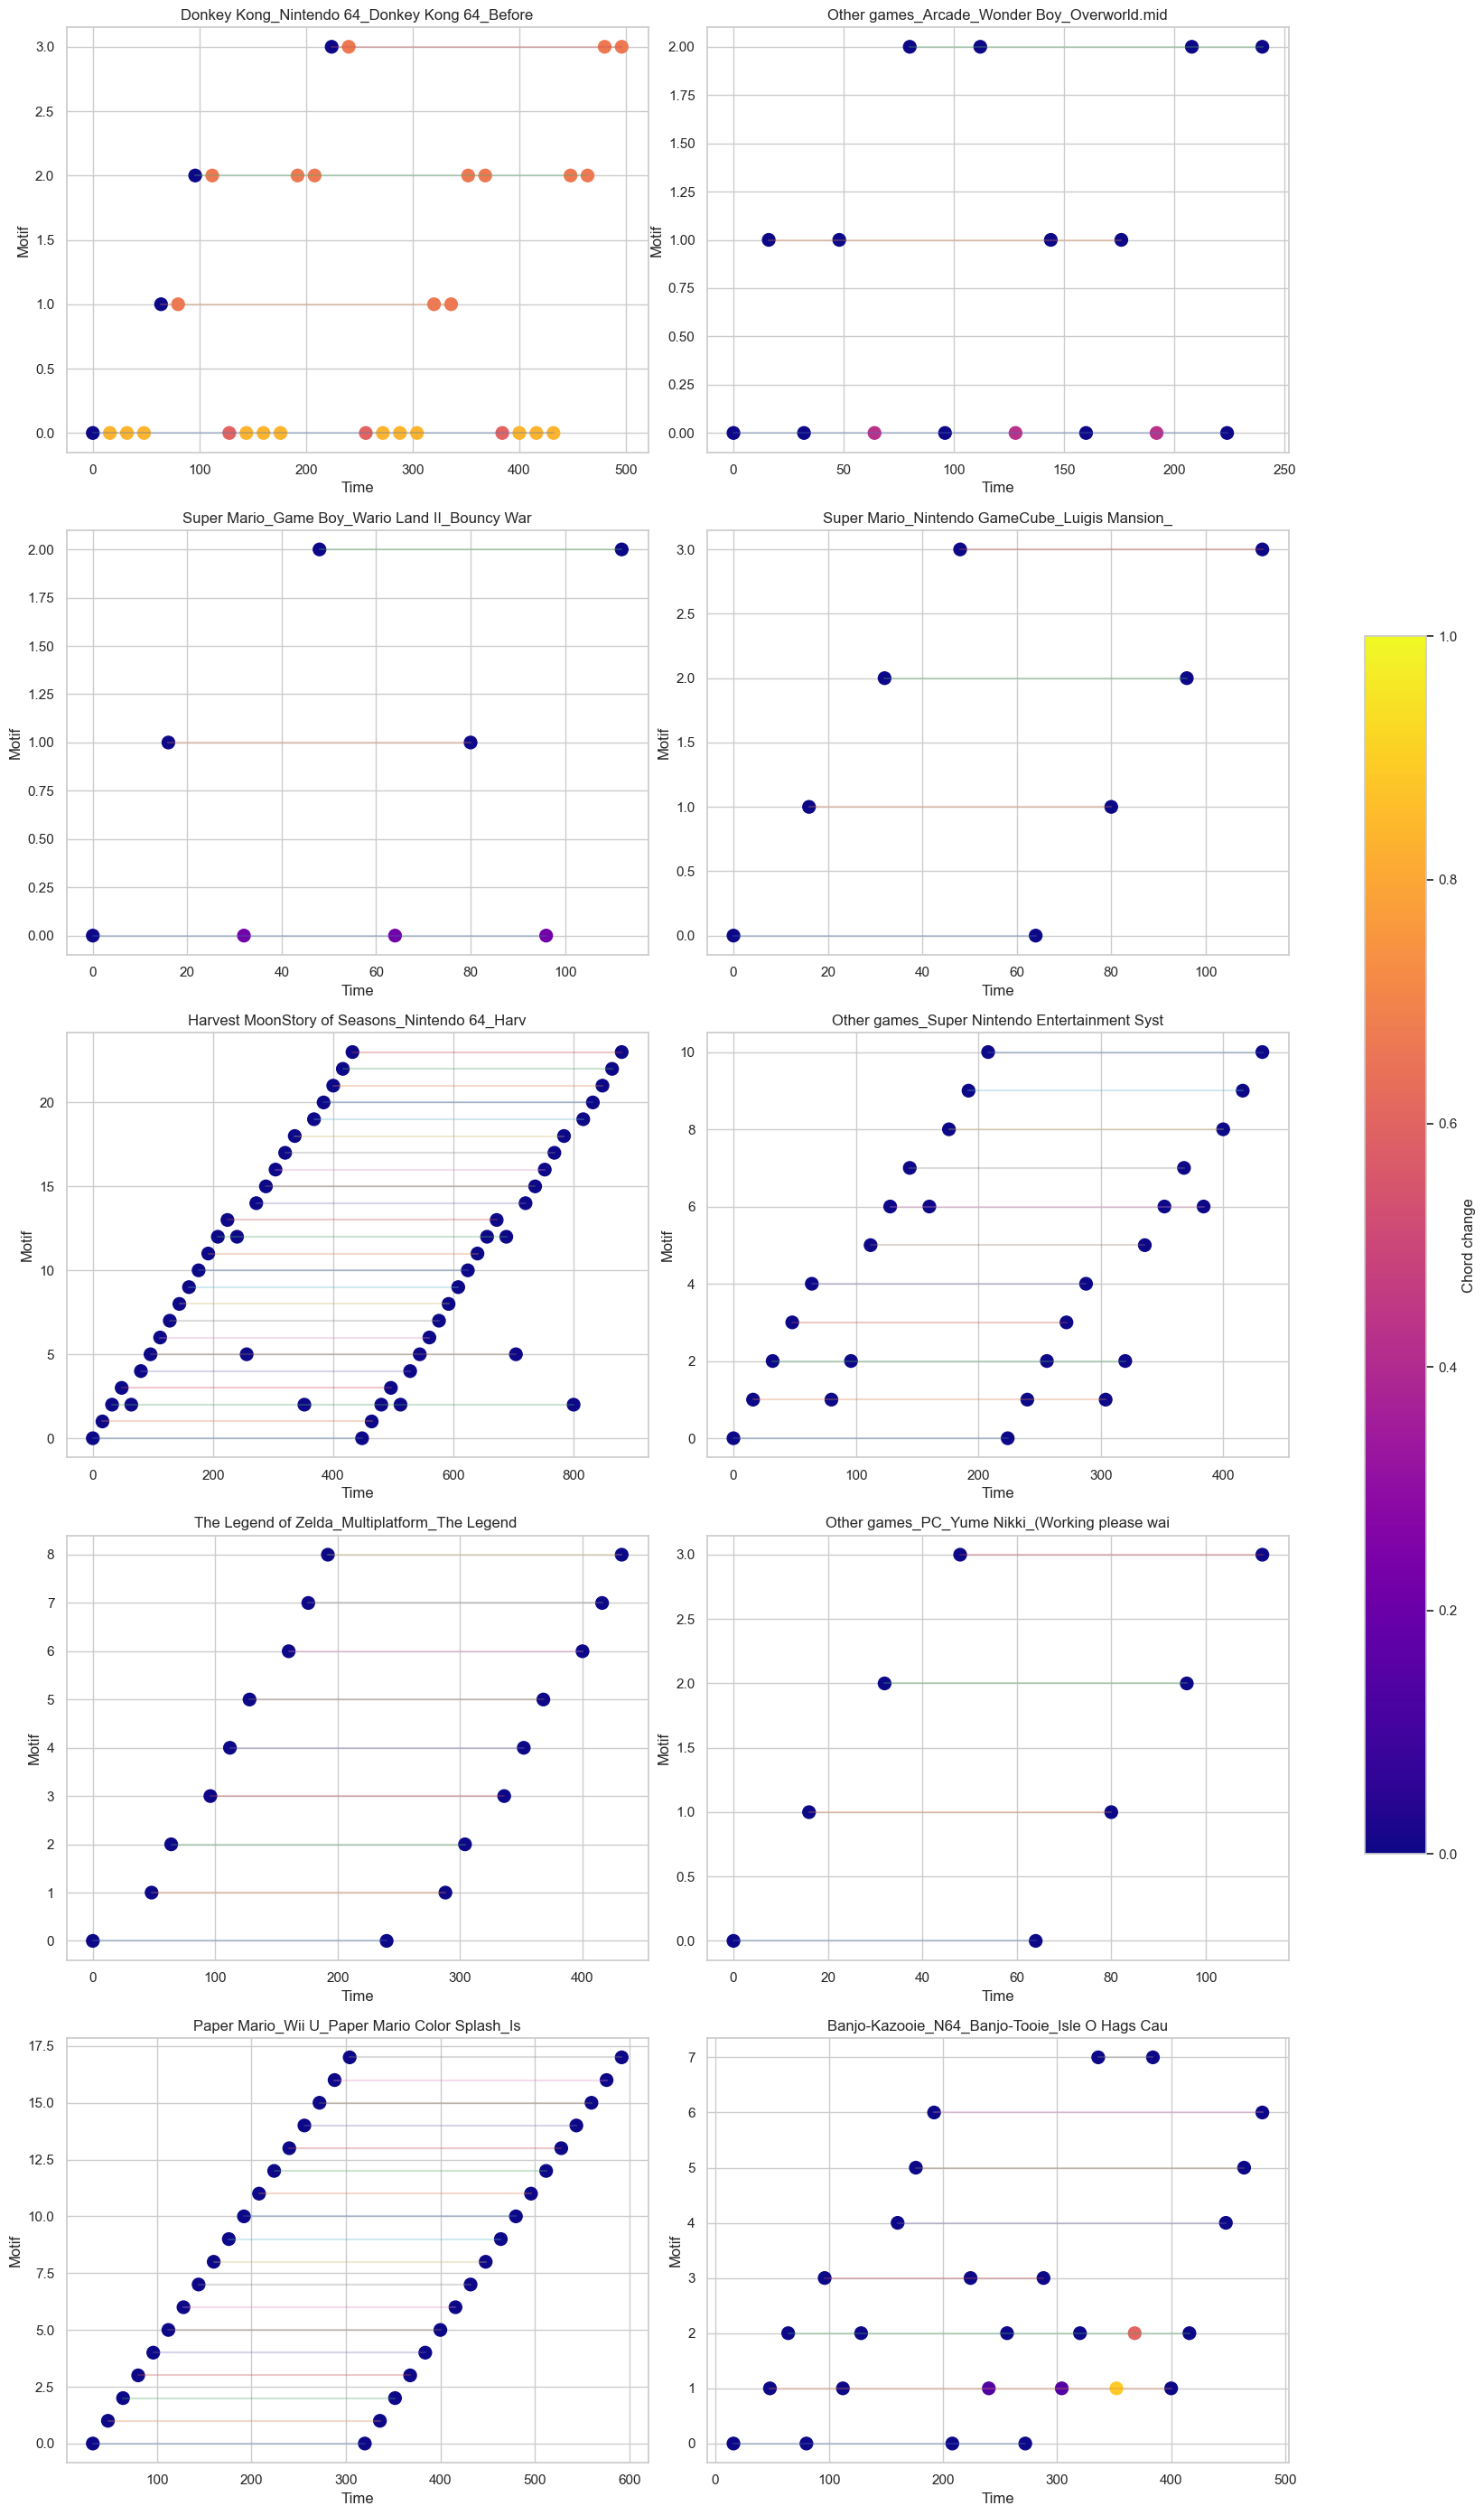

In [48]:
import math

fig, axes = plt.subplots(
    5,
    2,
    figsize=(18, 28)
)

axes = axes.flatten()

for ax, filename in zip(axes, top10_files):

    example_path = os.path.join(
        GAME_DIR,
        filename
    )

    try:

        pm = pretty_midi.PrettyMIDI(example_path)

        motifs, repeated = motif_timeline(pm)

        motif_id = 0

        for rhythm, idxs in repeated.items():

            prev_chord = None

            xs = []
            ys = []
            colors = []

            for idx in idxs:

                motif = motifs[idx]

                chord = set(motif["chord"])

                if prev_chord is None:
                    change = 0
                else:

                    intersection = len(prev_chord & chord)
                    union = len(prev_chord | chord)

                    if union == 0:
                        change = 0
                    else:
                        change = 1 - (
                            intersection / union
                        )

                xs.append(motif["start"])
                ys.append(motif_id)
                colors.append(change)

                prev_chord = chord

            ax.plot(
                xs,
                ys,
                alpha=0.3
            )

            sc = ax.scatter(
                xs,
                ys,
                c=colors,
                cmap="plasma",
                vmin=0,
                vmax=1,
                s=100
            )

            motif_id += 1

        short_title = filename[:45]

        ax.set_title(short_title)

        ax.set_xlabel("Time")
        ax.set_ylabel("Motif")

    except Exception as e:

        ax.set_title(f"FAILED:\n{filename}")

        print(filename, e)

plt.tight_layout()

cbar = fig.colorbar(
    sc,
    ax=axes,
    shrink=0.5
)

cbar.set_label("Chord change")

plt.savefig(
    "top10_game_motif_evolution.png",
    bbox_inches="tight"
)

plt.show()

In [49]:
top50 = game_df.sort_values(
    by="rhythm_repeat_rate",
    ascending=False
).head(50)

top50_files = top50["file"].tolist()

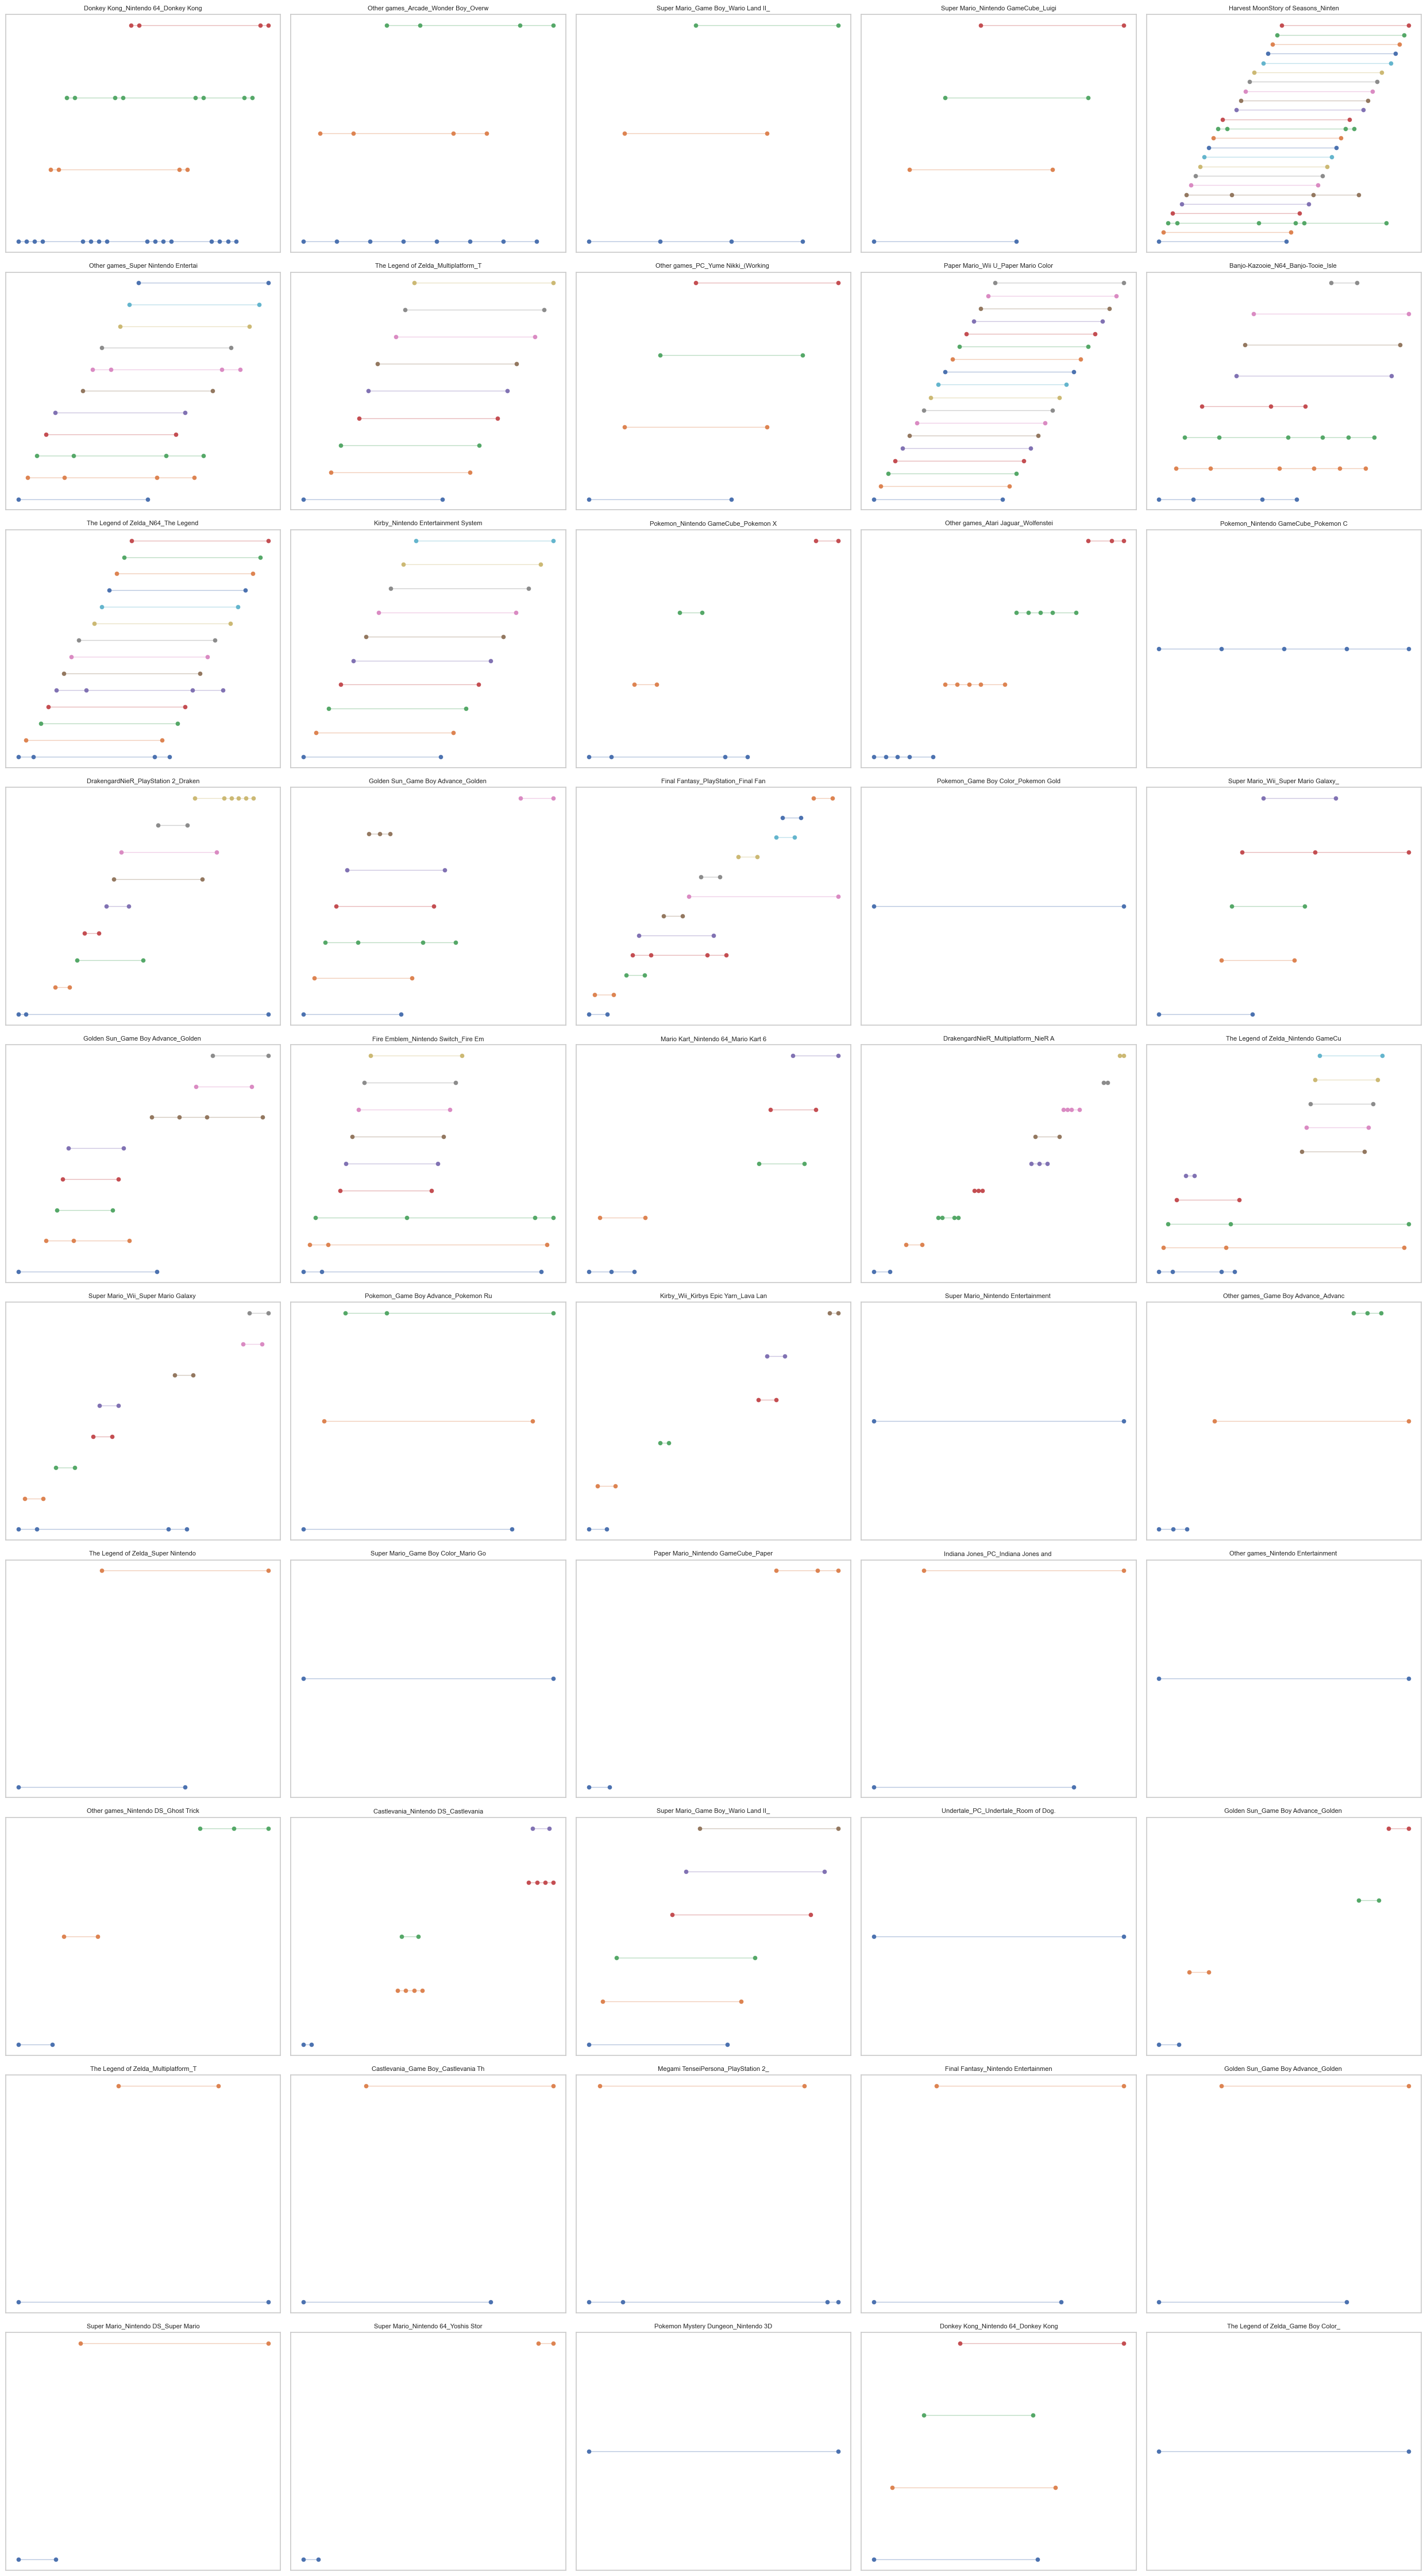

In [50]:
fig, axes = plt.subplots(
    10,
    5,
    figsize=(25, 45)
)

axes = axes.flatten()

for ax, filename in zip(axes, top50_files):

    example_path = os.path.join(
        GAME_DIR,
        filename
    )

    try:

        pm = pretty_midi.PrettyMIDI(example_path)

        motifs, repeated = motif_timeline(pm)

        motif_id = 0

        for rhythm, idxs in repeated.items():

            xs = []
            ys = []

            for idx in idxs:

                motif = motifs[idx]

                xs.append(motif["start"])
                ys.append(motif_id)

            ax.plot(
                xs,
                ys,
                alpha=0.4,
                linewidth=1
            )

            ax.scatter(
                xs,
                ys,
                s=20
            )

            motif_id += 1

        ax.set_title(
            filename[:35],
            fontsize=8
        )

        ax.set_xticks([])
        ax.set_yticks([])

    except Exception as e:

        ax.set_title("FAILED", fontsize=8)

        print(filename, e)

plt.tight_layout()

plt.savefig(
    "top50_motif_structures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
top50_pop = pop_df.sort_values(
    by="rhythm_repeat_rate",
    ascending=False
).head(50)

top50_pop_files = top50_pop["file"].tolist()

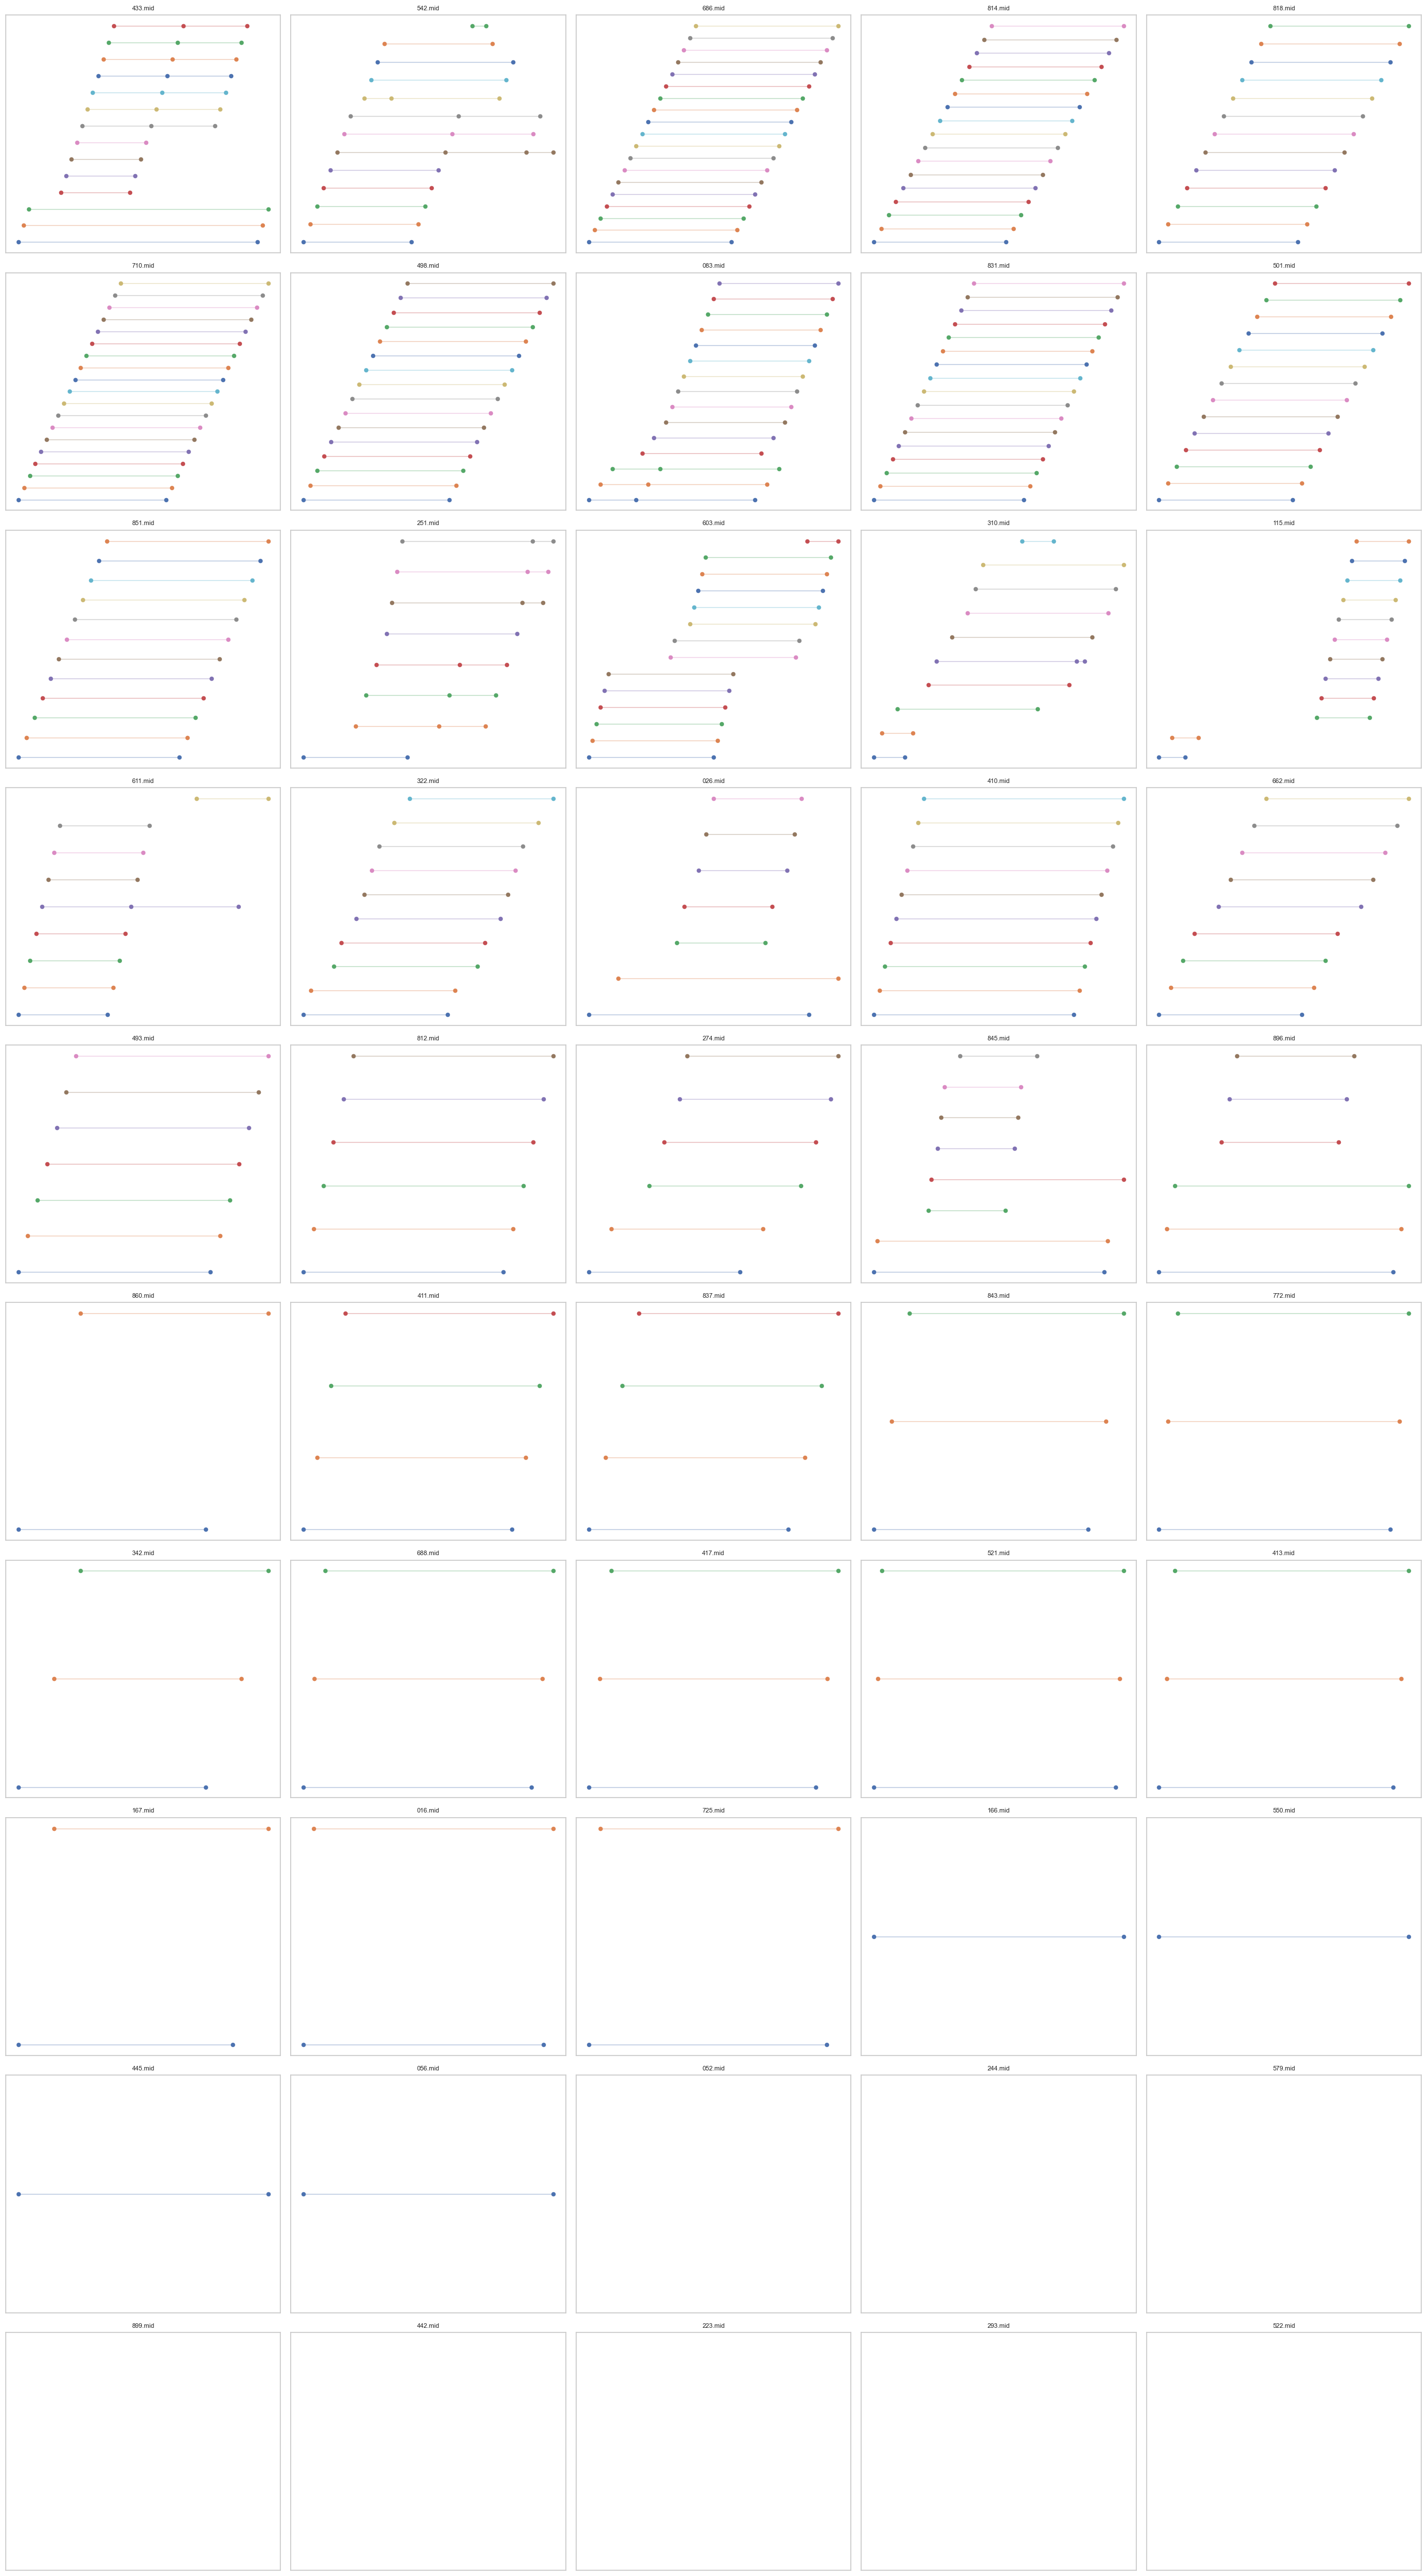

In [52]:
fig, axes = plt.subplots(
    10,
    5,
    figsize=(25, 45)
)

axes = axes.flatten()

for ax, filename in zip(axes, top50_pop_files):

    example_path = os.path.join(
        POP_DIR,
        filename
    )

    try:

        pm = pretty_midi.PrettyMIDI(example_path)

        motifs, repeated = motif_timeline(pm)

        motif_id = 0

        for rhythm, idxs in repeated.items():

            xs = []
            ys = []

            for idx in idxs:

                motif = motifs[idx]

                xs.append(motif["start"])
                ys.append(motif_id)

            ax.plot(
                xs,
                ys,
                alpha=0.4,
                linewidth=1
            )

            ax.scatter(
                xs,
                ys,
                s=20
            )

            motif_id += 1

        ax.set_title(
            filename[:35],
            fontsize=8
        )

        ax.set_xticks([])
        ax.set_yticks([])

    except Exception as e:

        ax.set_title("FAILED", fontsize=8)

        print(filename, e)

plt.tight_layout()

plt.savefig(
    "top50_pop_motif_structures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
top50_classical = classical_df.sort_values(
    by="rhythm_repeat_rate",
    ascending=False
).head(50)

top50_classical_files = top50_classical["file"].tolist()

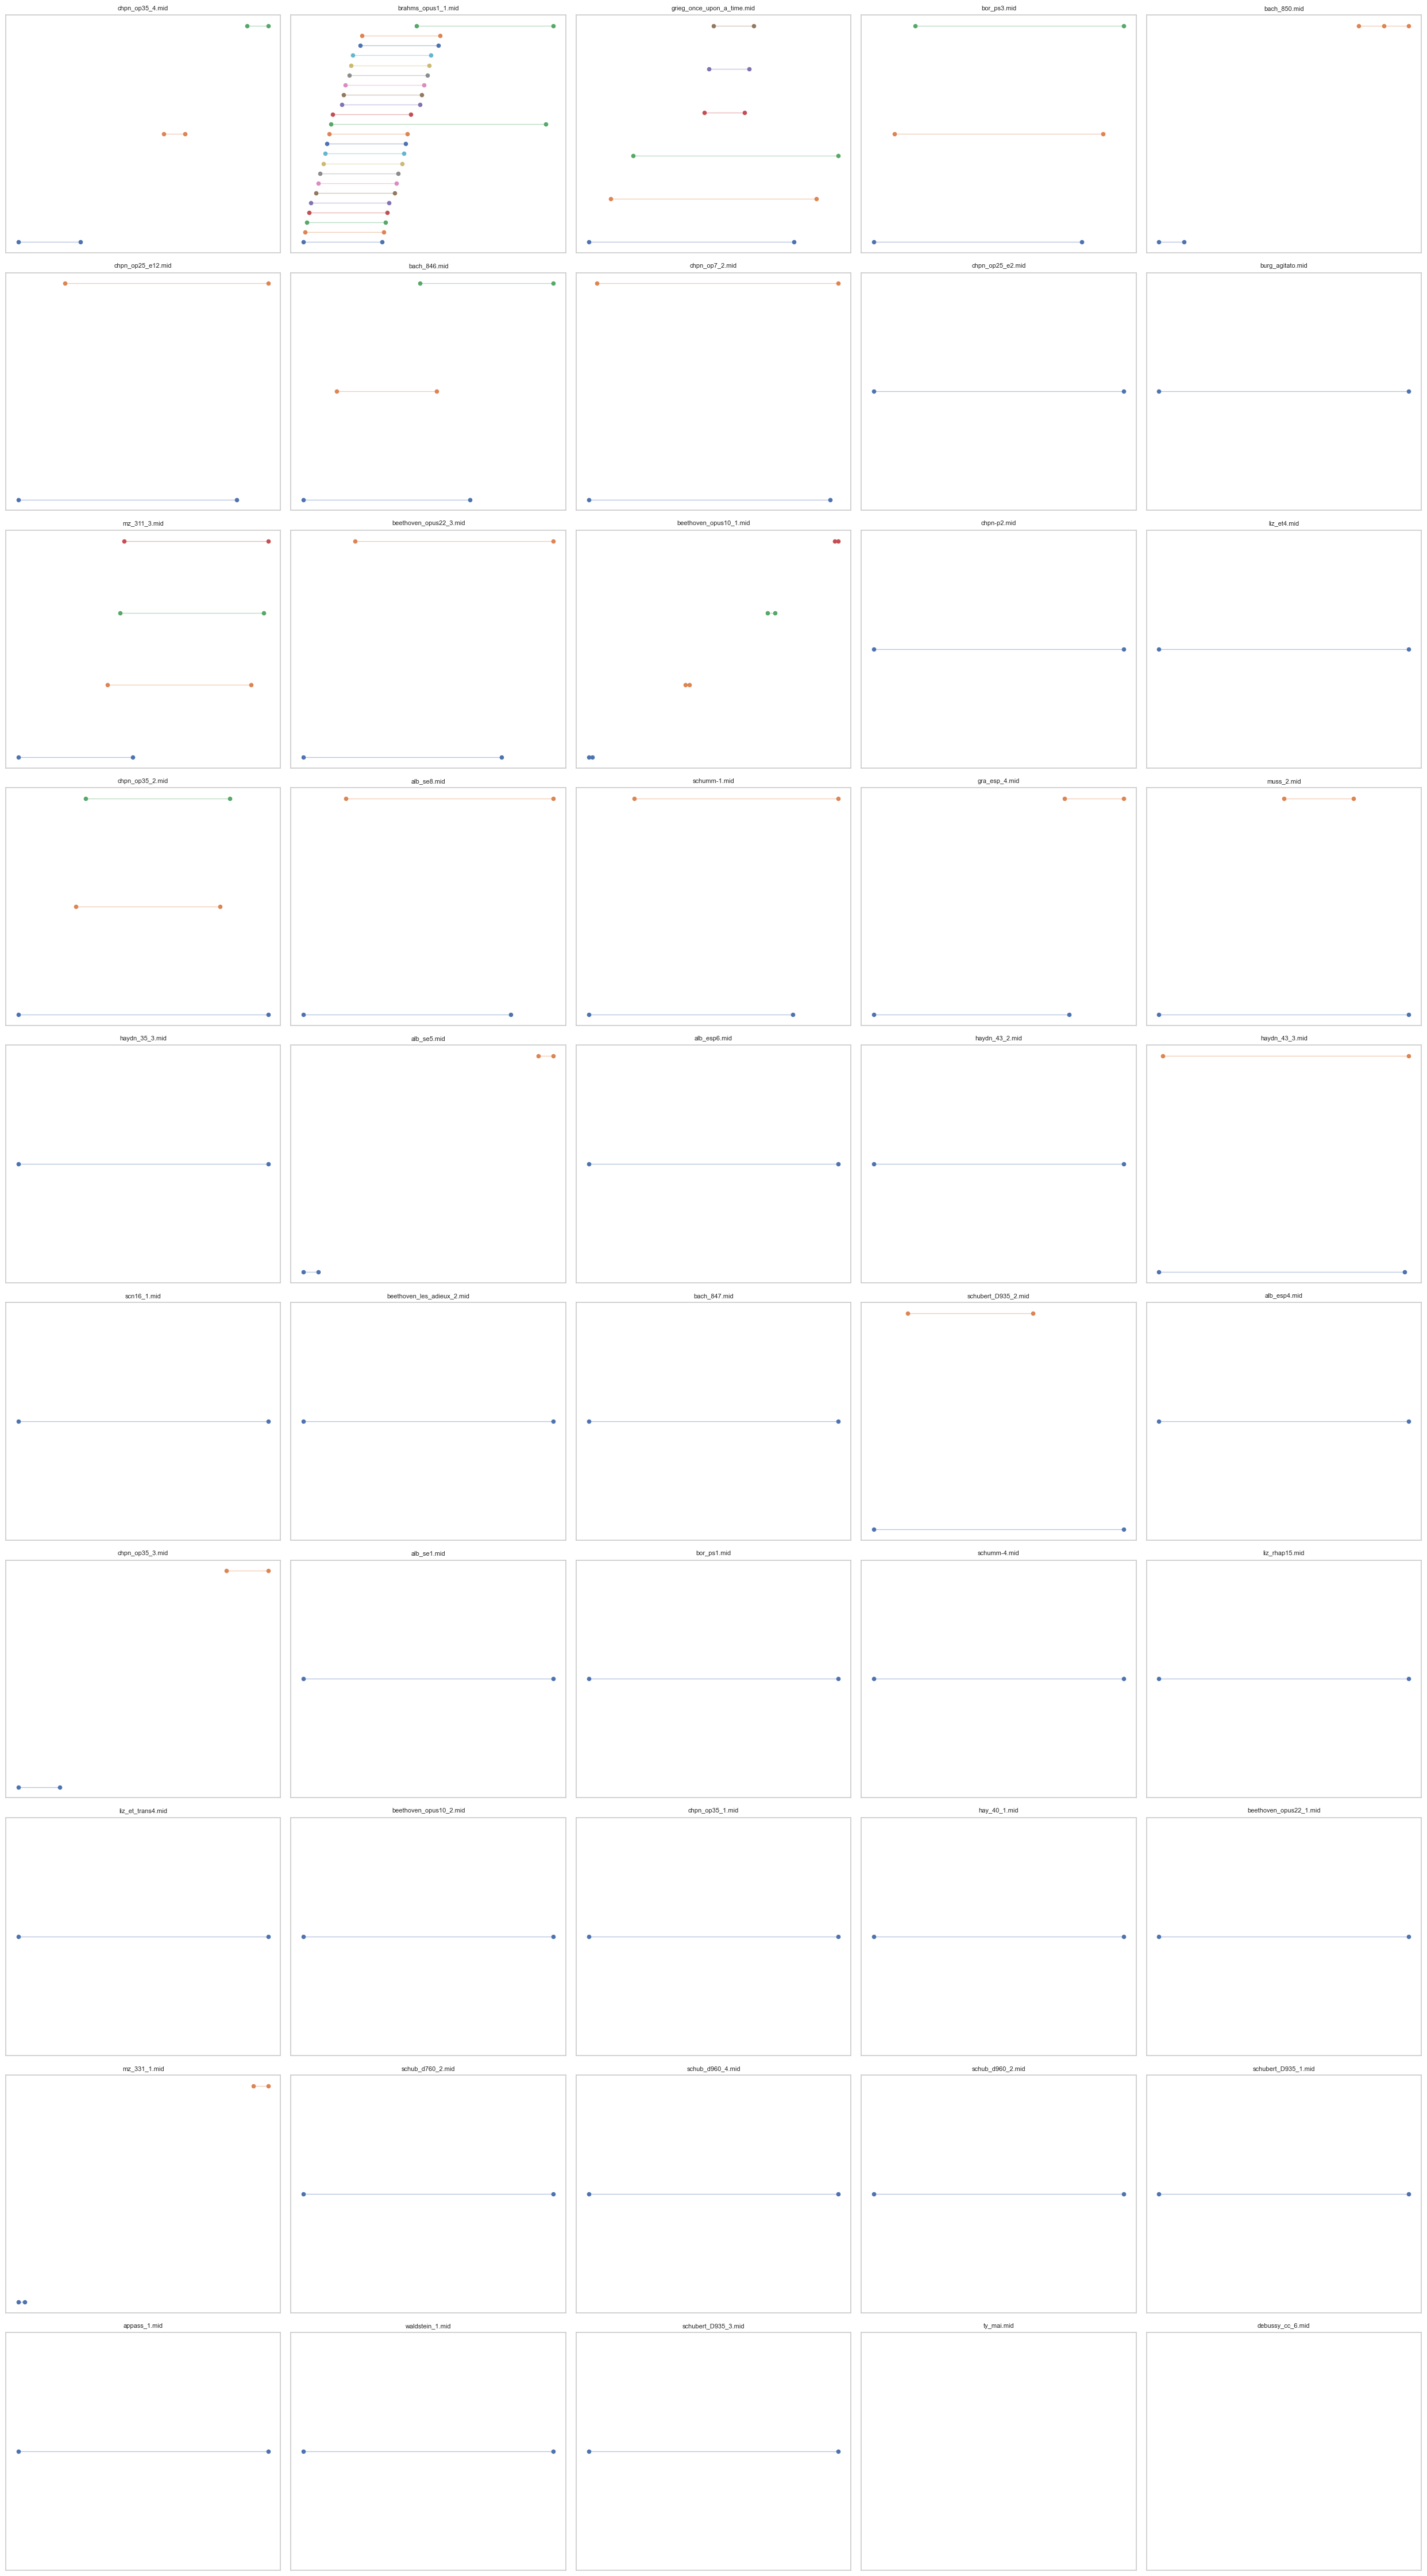

In [54]:
fig, axes = plt.subplots(
    10,
    5,
    figsize=(25, 45)
)

axes = axes.flatten()

for ax, filename in zip(axes, top50_classical_files):

    example_path = os.path.join(
        CLASSICAL_DIR,
        filename
    )

    try:

        pm = pretty_midi.PrettyMIDI(example_path)

        motifs, repeated = motif_timeline(pm)

        motif_id = 0

        for rhythm, idxs in repeated.items():

            xs = []
            ys = []

            for idx in idxs:

                motif = motifs[idx]

                xs.append(motif["start"])
                ys.append(motif_id)

            ax.plot(
                xs,
                ys,
                alpha=0.4,
                linewidth=1
            )

            ax.scatter(
                xs,
                ys,
                s=20
            )

            motif_id += 1

        ax.set_title(
            filename[:35],
            fontsize=8
        )

        ax.set_xticks([])
        ax.set_yticks([])

    except Exception as e:

        ax.set_title("FAILED", fontsize=8)

        print(filename, e)

plt.tight_layout()

plt.savefig(
    "top50_classical_motif_structures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
def get_piece_length(pm):

    end_time = 0

    for instrument in pm.instruments:
        for note in instrument.notes:
            end_time = max(end_time, note.end)

    return end_time


def repeat_motifs_to_target(motifs, target_windows):

    repeated = []

    original_length = motifs[-1]["window_start"] + 1

    current_offset = 0

    while current_offset < target_windows:

        for motif in motifs:

            new_motif = motif.copy()

            new_motif["window_start"] = (
                motif["window_start"]
                + current_offset
            )

            repeated.append(new_motif)

        current_offset += original_length

    return repeated

In [64]:
classical_lengths = []

for file in os.listdir(CLASSICAL_DIR):

    if file.endswith(".mid"):

        path = os.path.join(CLASSICAL_DIR, file)

        pm = pretty_midi.PrettyMIDI(path)

        motifs = make_windows(pm)

        classical_lengths.append(len(motifs))

target_windows = int(np.median(classical_lengths))

print("target windows:", target_windows)

target windows: 48


In [65]:
def recurrence_structure_features(pm):

    motifs, repeated = motif_timeline(pm)

    if len(repeated) == 0:

        return {
            "n_repeated_motifs": 0,
            "motif_rate": 0,
            "avg_recurrence_count": 0,
            "avg_recurrence_span": 0,
            "max_recurrence_span": 0,
            "avg_motif_density": 0,
        }

    recurrence_counts = []
    recurrence_spans = []
    motif_densities = []

    total_windows = len(motifs)

    for rhythm, idxs in repeated.items():

        idxs = sorted(idxs)

        recurrence_counts.append(
            len(idxs) / total_windows
        )

        span = (
            idxs[-1] - idxs[0]
        ) / total_windows

        recurrence_spans.append(span)

        motif_density = len(idxs) / total_windows

        motif_densities.append(motif_density)

    return {

        "n_repeated_motifs":
            len(repeated),

        "motif_rate":
            len(repeated) / total_windows,

        "avg_recurrence_count":
            np.mean(recurrence_counts),

        "avg_recurrence_span":
            np.mean(recurrence_spans),

        "max_recurrence_span":
            np.max(recurrence_spans),

        "avg_motif_density":
            np.mean(motif_densities),
    }

In [74]:
def repeat_pretty_midi(pm, repeats=4):

    new_pm = pretty_midi.PrettyMIDI()

    piece_length = pm.get_end_time()

    for r in range(repeats):

        offset = r * piece_length

        for instrument in pm.instruments:

            new_inst = pretty_midi.Instrument(
                program=instrument.program,
                is_drum=instrument.is_drum,
                name=instrument.name
            )

            for note in instrument.notes:

                new_note = pretty_midi.Note(
                    velocity=note.velocity,
                    pitch=note.pitch,
                    start=note.start + offset,
                    end=note.end + offset
                )

                new_inst.notes.append(new_note)

            new_pm.instruments.append(new_inst)

    return new_pm


def recurrence_structure_features(pm):

    motifs, repeated = motif_timeline(pm)

    if len(repeated) == 0:

        return {
            "n_repeated_motifs": 0,
            "motif_rate": 0,
            "avg_recurrence_count": 0,
            "avg_recurrence_span": 0,
            "max_recurrence_span": 0,
            "avg_motif_density": 0,
        }

    recurrence_counts = []
    recurrence_spans = []
    motif_densities = []

    total_windows = len(motifs)

    for rhythm, idxs in repeated.items():

        idxs = sorted(idxs)

        recurrence_counts.append(
            len(idxs) / total_windows
        )

        span = (
            idxs[-1] - idxs[0]
        ) / total_windows

        recurrence_spans.append(span)

        motif_density = len(idxs) / total_windows

        motif_densities.append(motif_density)

    return {

        "n_repeated_motifs":
            len(repeated),

        "motif_rate":
            len(repeated) / total_windows
            if total_windows > 0 else 0,

        "avg_recurrence_count":
            np.mean(recurrence_counts)
            if recurrence_counts else 0,

        "avg_recurrence_span":
            np.mean(recurrence_spans)
            if recurrence_spans else 0,

        "max_recurrence_span":
            np.max(recurrence_spans)
            if recurrence_spans else 0,

        "avg_motif_density":
            np.mean(motif_densities)
            if motif_densities else 0,
    }


structure_rows = []

for genre, folder in [
    ("classical", CLASSICAL_DIR),
    ("pop", POP_DIR),
    ("game", GAME_DIR),
]:

    for file in os.listdir(folder):

        if not (
            file.endswith(".mid")
            or
            file.endswith(".midi")
        ):
            continue

        path = os.path.join(folder, file)

        try:

            pm = pretty_midi.PrettyMIDI(path)

            # simulate looping playback for game music
            if genre == "game":

                pm = repeat_pretty_midi(
                    pm,
                    repeats=4
                )

            structure = recurrence_structure_features(pm)

            row = {
                "genre": genre,
                "file": file,

                "n_repeated_motifs":
                    structure["n_repeated_motifs"],

                "motif_rate":
                    structure["motif_rate"],

                "avg_recurrence_count":
                    structure["avg_recurrence_count"],

                "avg_recurrence_span":
                    structure["avg_recurrence_span"],

                "max_recurrence_span":
                    structure["max_recurrence_span"],

                "avg_motif_density":
                    structure["avg_motif_density"],
            }

            structure_rows.append(row)

            print("processed:", file)

        except Exception as e:

            print("failed:", file, e)

structure_df = pd.DataFrame(structure_rows)

print(structure_df.head())

processed: haydn_43_1.mid
processed: ty_august.mid
processed: muss_2.mid
processed: waldstein_1.mid
processed: schumm-1.mid
processed: chpn_op23.mid
processed: chpn-p19.mid
processed: chpn_op7_2.mid
processed: beethoven_opus90_2.mid
processed: chpn-p18.mid
processed: chpn-p24.mid
processed: mendel_op19_1.mid
processed: grieg_kobold.mid
processed: muss_3.mid
processed: haydn_43_2.mid
processed: muss_1.mid
processed: burg_sylphen.mid
processed: waldstein_2.mid
processed: schumm-2.mid
processed: burg_quelle.mid
processed: mendel_op19_3.mid
processed: schub_d960_4.mid
processed: chpn_op7_1.mid
processed: schum_abegg.mid
processed: gra_esp_4.mid
processed: islamei.mid
processed: beethoven_opus90_1.mid
processed: mendel_op19_2.mid
processed: schumm-3.mid
processed: waldstein_3.mid
processed: haydn_8_4.mid
processed: haydn_43_3.mid
processed: muss_4.mid
processed: bach_847.mid
processed: scn68_10.mid
processed: ty_dezember.mid
processed: scn15_10.mid
processed: mendel_op19_6.mid
processed: sc

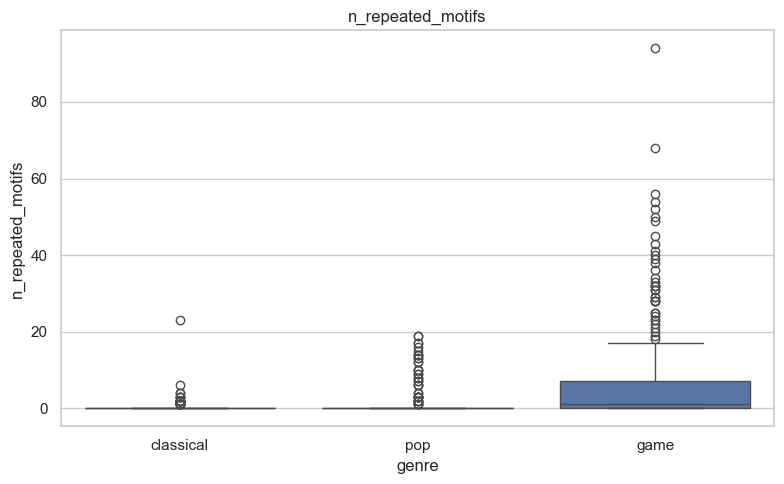

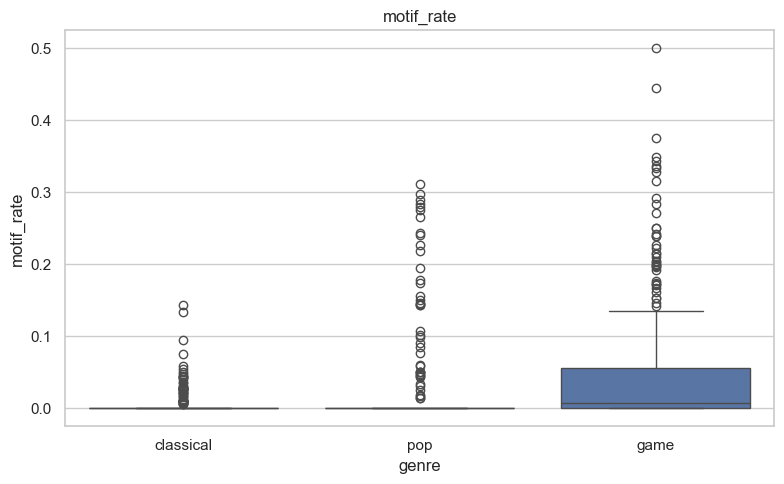

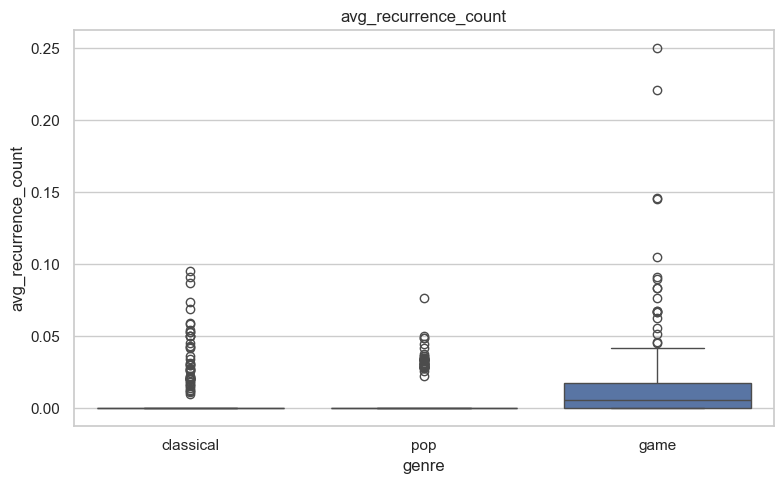

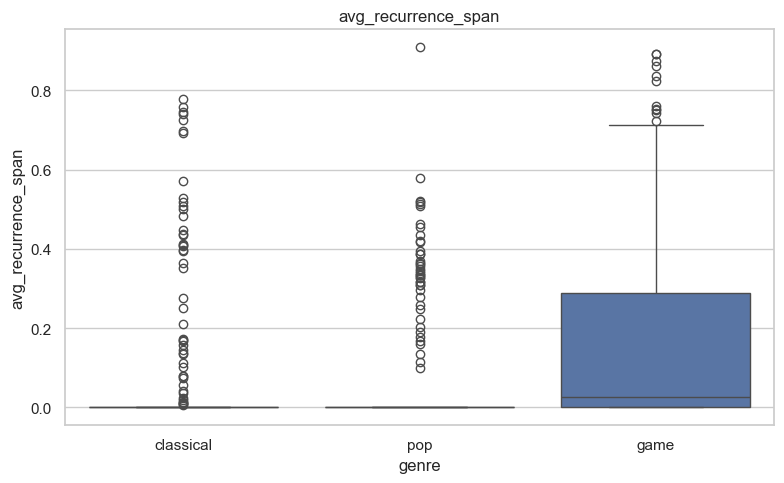

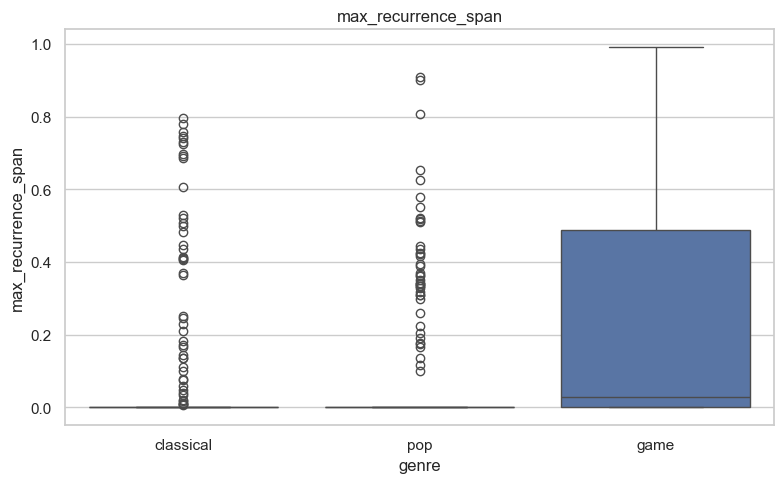

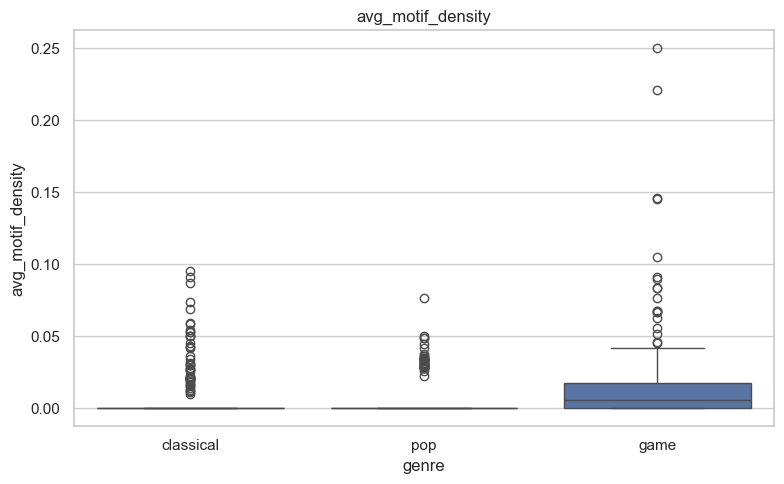

In [75]:
structure_features = [
    "n_repeated_motifs",
    "motif_rate",
    "avg_recurrence_count",
    "avg_recurrence_span",
    "max_recurrence_span",
    "avg_motif_density",
]

for feature in structure_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=structure_df,
        x="genre",
        y=feature
    )

    plt.title(feature)

    plt.tight_layout()

    plt.savefig(
        f"{feature}_expanded_structure_boxplot.png"
    )

    plt.show()

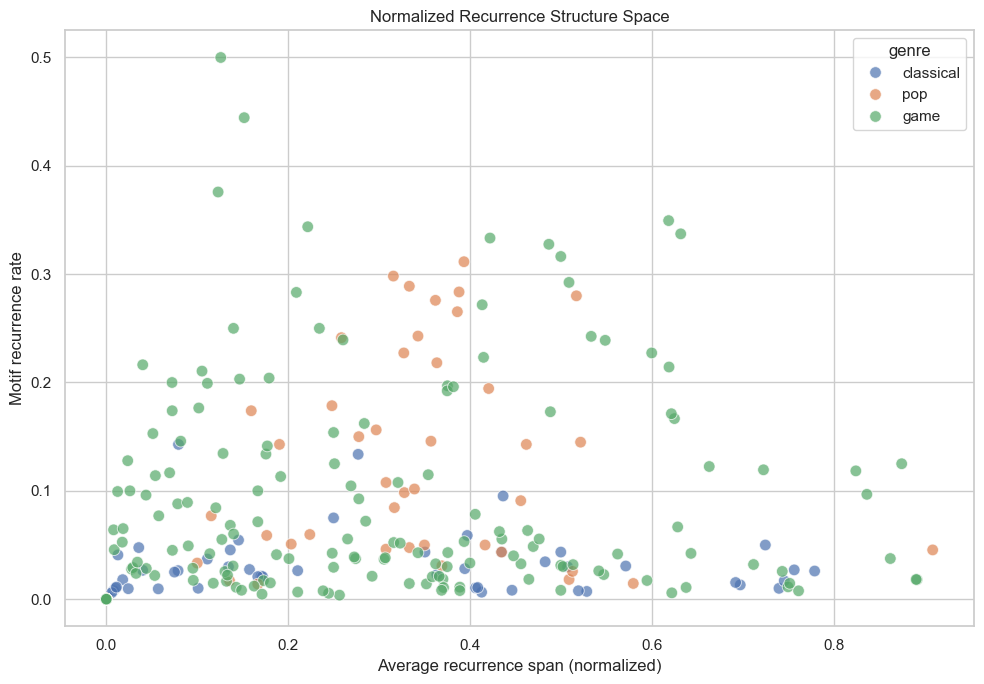

In [76]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=structure_df,
    x="avg_recurrence_span",
    y="motif_rate",
    hue="genre",
    alpha=0.7,
    s=70
)

plt.title(
    "Normalized Recurrence Structure Space"
)

plt.xlabel(
    "Average recurrence span (normalized)"
)

plt.ylabel(
    "Motif recurrence rate"
)

plt.tight_layout()

plt.savefig(
    "expanded_recurrence_structure_space.png"
)

plt.show()

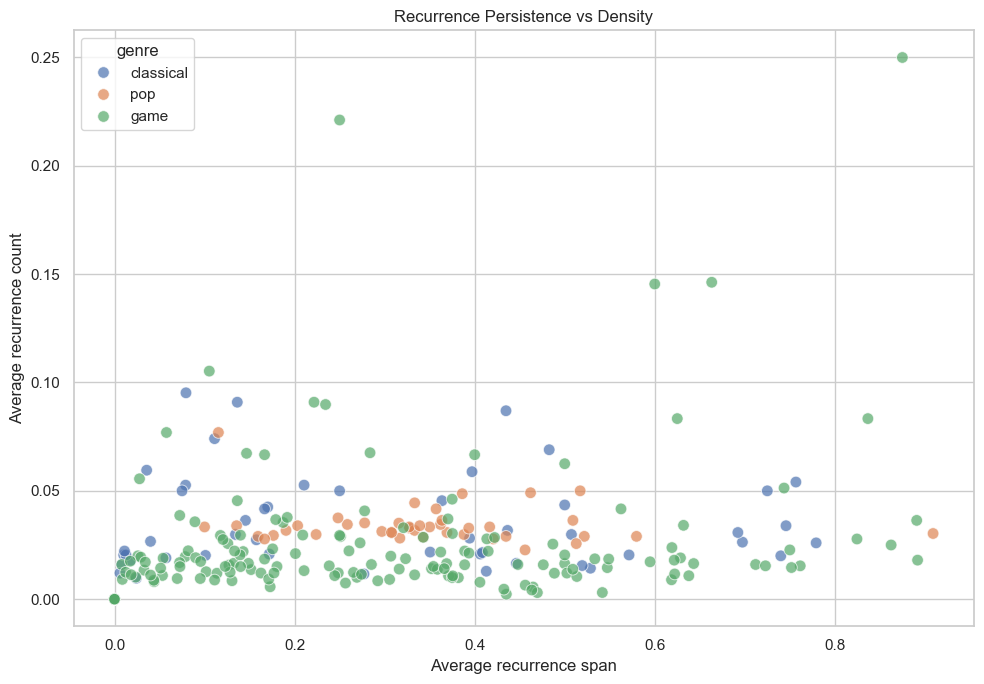

In [77]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=structure_df,
    x="avg_recurrence_span",
    y="avg_recurrence_count",
    hue="genre",
    alpha=0.7,
    s=70
)

plt.title(
    "Recurrence Persistence vs Density"
)

plt.xlabel(
    "Average recurrence span"
)

plt.ylabel(
    "Average recurrence count"
)

plt.tight_layout()

plt.savefig(
    "recurrence_persistence_density.png"
)

plt.show()